<a href="https://colab.research.google.com/github/kshero18/Research_Project_Code/blob/main/Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

file_path = '/content/ModifiedCallCenterTwo.xlsx'  # Get the uploaded file name
df = pd.read_excel(file_path, engine="openpyxl")
print(df.head())



  Call Id  Agent        Date      Time              Topic Answered (Y/N)  \
0  ID0001  Sarah  2021-01-01  09:12:58   Contract related              Y   
1  ID0002  Sarah  2021-01-01  09:12:58  Technical Support              Y   
2  ID0003  Sarah  2021-01-01  09:47:31   Contract related              Y   
3  ID0004  Sarah  2021-01-01  09:47:31   Contract related              Y   
4  ID0005  Sarah  2021-01-01  10:00:29    Payment related              Y   

  Resolved  Speed of answer in seconds AvgTalkDuration  Satisfaction rating  
0        Y                       109.0        00:02:23                  3.0  
1        N                        70.0        00:04:02                  3.0  
2        Y                        10.0        00:02:11                  3.0  
3        Y                        53.0        00:00:37                  2.0  
4        Y                        95.0        00:01:00                  3.0  


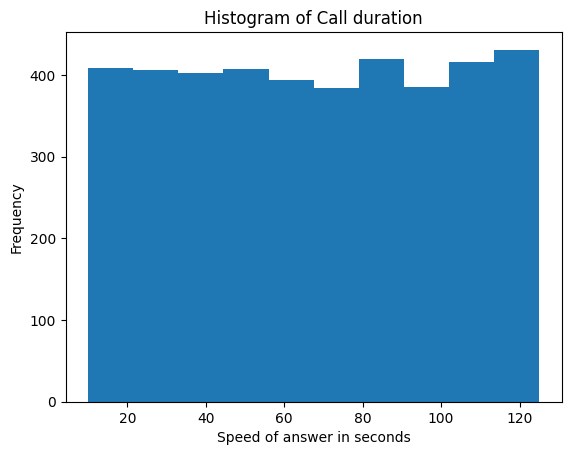

In [ ]:
# prompt: create historgram for the data

import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame and you want a histogram for the 'Call duration' column
# Replace 'Call duration' with the actual column name you want to plot
plt.hist(df['Speed of answer in seconds'], bins=10)  # Adjust the number of bins as needed
plt.xlabel('Speed of answer in seconds')
plt.ylabel('Frequency')
plt.title('Histogram of Call duration')
plt.show()


In [ ]:
print("Dataset Overview:")
print(df.info())

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Call Id                     5000 non-null   object 
 1   Agent                       5000 non-null   object 
 2   Date                        5000 non-null   object 
 3   Time                        5000 non-null   object 
 4   Topic                       5000 non-null   object 
 5   Answered (Y/N)              5000 non-null   object 
 6   Resolved                    5000 non-null   object 
 7   Speed of answer in seconds  4054 non-null   float64
 8   AvgTalkDuration             4054 non-null   object 
 9   Satisfaction rating         4054 non-null   float64
dtypes: float64(2), object(8)
memory usage: 390.8+ KB
None


The date column is converted to datetime. The speed of answer in seconds column can be converted to numeric rather than float. Similarly for satisfactory rating column.

In [ ]:
# Convert necessary columns
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Speed of answer in seconds"] = pd.to_numeric(df["Speed of answer in seconds"], errors="coerce")
df["Satisfaction rating"] = pd.to_numeric(df["Satisfaction rating"], errors="coerce")

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Call Id                     5000 non-null   object        
 1   Agent                       5000 non-null   object        
 2   Date                        5000 non-null   datetime64[ns]
 3   Time                        5000 non-null   object        
 4   Topic                       5000 non-null   object        
 5   Answered (Y/N)              5000 non-null   object        
 6   Resolved                    5000 non-null   object        
 7   Speed of answer in seconds  4054 non-null   float64       
 8   AvgTalkDuration             4054 non-null   object        
 9   Satisfaction rating         4054 non-null   float64       
dtypes: datetime64[ns](1), float64(2), object(7)
memory usage: 390.8+ KB
None


In [ ]:
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
                                Date  Speed of answer in seconds  \
count                           5000                 4054.000000   
mean   2021-02-13 05:32:38.400000256                   67.520720   
min              2021-01-01 00:00:00                   10.000000   
25%              2021-01-23 00:00:00                   39.000000   
50%              2021-02-13 00:00:00                   68.000000   
75%              2021-03-06 00:00:00                   97.000000   
max              2021-03-31 00:00:00                  125.000000   
std                              NaN                   33.592872   

       Satisfaction rating  
count          4054.000000  
mean              3.403552  
min               1.000000  
25%               3.000000  
50%               3.000000  
75%               4.000000  
max               5.000000  
std               1.212220  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df["AvgTalkDuration"] = df["AvgTalkDuration"].astype(str).apply(lambda x: sum(int(t) * 60**i for i, t in enumerate(reversed(x.split(":")))) if ":" in str(x) else np.nan)


In [ ]:
df.isnull().sum()


,0
Call Id,0
Agent,0
Date,0
Time,0
Topic,0
Answered (Y/N),0
Resolved,0
Speed of answer in seconds,946
AvgTalkDuration,946
Satisfaction rating,946


In [ ]:
!pip install simpy

In [ ]:
# Calls by topic
print("\nCall Distribution by Topic:")
print(df["Topic"].value_counts())

# Calls by agent
print("\nCall Distribution by Agent:")
print(df["Agent"].value_counts())

# Resolution rate
print("\nResolution Rate:")
print(df["Resolved"].value_counts(normalize=True) * 100)

# Average speed of answer and talk duration
print("\nAverage Speed of Answer:", df["Speed of answer in seconds"].mean(), "seconds")
print("Average Talk Duration:", df["AvgTalkDuration"].mean(), "seconds")

# Satisfaction rating distribution
print("\nSatisfaction Rating Distribution (%):")
print(df["Satisfaction rating"].value_counts(normalize=True) * 100)


Call Distribution by Topic:
Topic
Streaming            1022
Technical Support    1019
Payment related      1007
Contract related      976
Admin Support         976
Name: count, dtype: int64

Call Distribution by Agent:
Agent
Sarah    3284
Tom      1716
Name: count, dtype: int64

Resolution Rate:
Resolved
Y    72.92
N    27.08
Name: proportion, dtype: float64

Average Speed of Answer: 67.52072027627035 seconds
Average Talk Duration: 224.92279230389738 seconds

Satisfaction Rating Distribution (%):
Satisfaction rating
3.0    30.044401
4.0    29.107055
5.0    20.794277
1.0    10.286137
2.0     9.768130
Name: proportion, dtype: float64


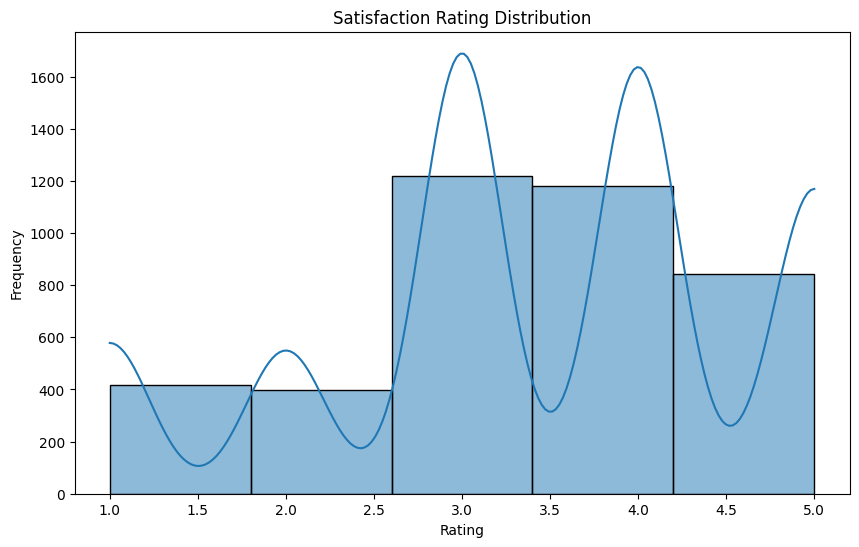

In [ ]:
# Visualization
plt.figure(figsize=(10, 6))
sns.histplot(df["Satisfaction rating"].dropna(), bins=5, kde=True)
plt.title("Satisfaction Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

Checking the distribution


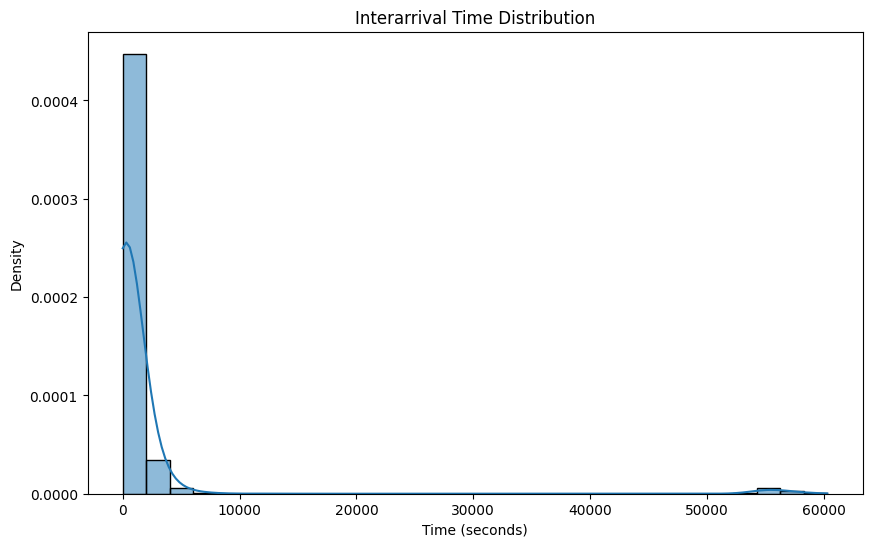

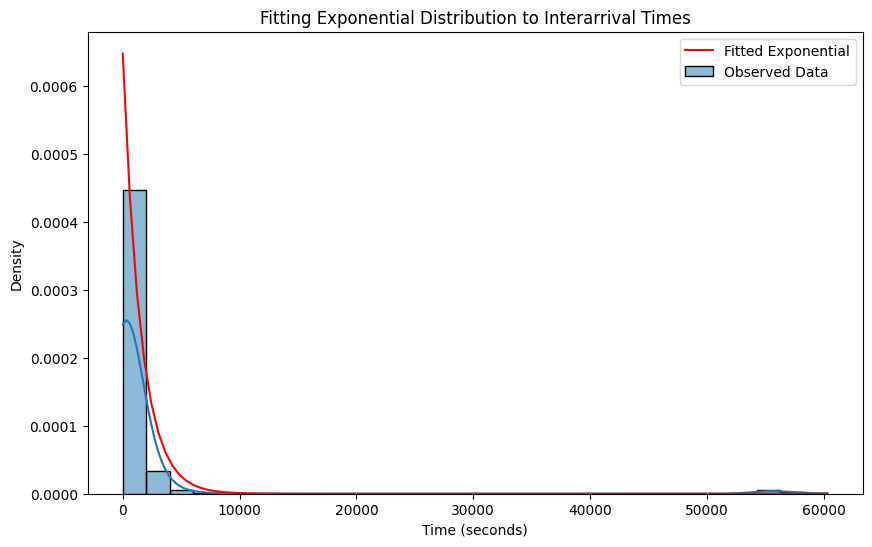


Kolmogorov-Smirnov Test for Exponential Distribution: p-value = 0.00000
Interarrival times do NOT follow an exponential distribution.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Convert Date and Time to a single datetime column
df["Datetime"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"].astype(str))

# Sort by Datetime
df = df.sort_values(by="Datetime")

# Compute interarrival times (in seconds)
df["Interarrival Time"] = df["Datetime"].diff().dt.total_seconds().dropna()

# Plot Histogram and KDE for Interarrival Times
plt.figure(figsize=(10, 6))
sns.histplot(df["Interarrival Time"], bins=30, kde=True, stat="density")
plt.title("Interarrival Time Distribution")
plt.xlabel("Time (seconds)")
plt.ylabel("Density")
plt.show()

# Fit an Exponential Distribution (fix: only returns loc & scale)
loc, scale = stats.expon.fit(df["Interarrival Time"].dropna())

# Generate fitted distribution
x = np.linspace(df["Interarrival Time"].min(), df["Interarrival Time"].max(), 100)
pdf = stats.expon.pdf(x, loc, scale)

plt.figure(figsize=(10, 6))
sns.histplot(df["Interarrival Time"], bins=30, kde=True, stat="density", label="Observed Data")
plt.plot(x, pdf, label="Fitted Exponential", color="red")
plt.legend()
plt.title("Fitting Exponential Distribution to Interarrival Times")
plt.xlabel("Time (seconds)")
plt.ylabel("Density")
plt.show()

# Test if interarrival times fit an exponential distribution
ks_stat, p_value = stats.kstest(df["Interarrival Time"].dropna(), 'expon', args=(loc, scale))
print(f"\nKolmogorov-Smirnov Test for Exponential Distribution: p-value = {p_value:.5f}")

# If p-value > 0.05, the data follows an exponential distribution
if p_value > 0.05:
    print("Interarrival times follow an exponential distribution.")
else:
    print("Interarrival times do NOT follow an exponential distribution.")


<ipython-input-58-cda80fa72f39>:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  calls_per_hour = df["Call Count"].resample("H").sum()


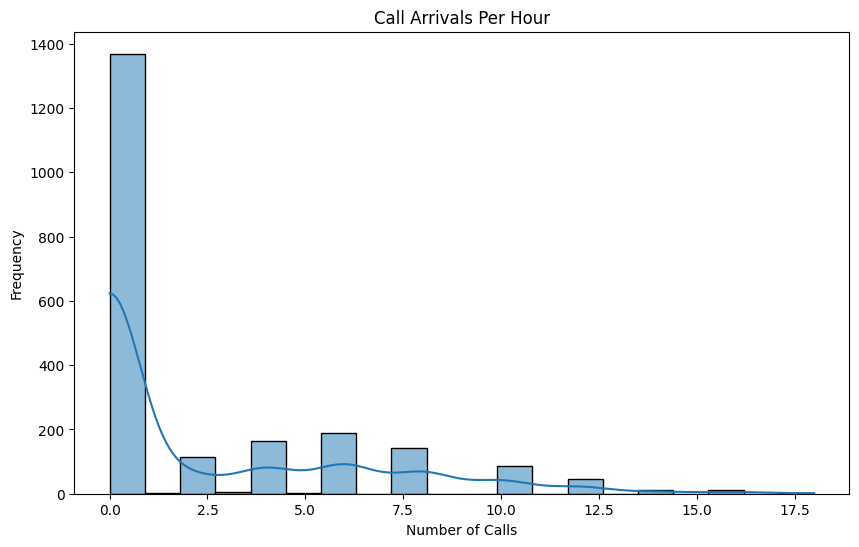

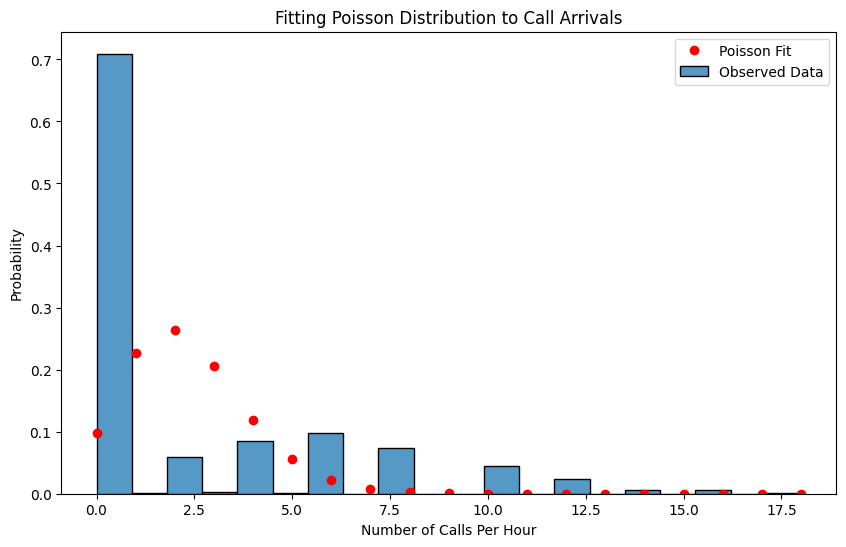

In [ ]:
# Set time interval (e.g., 1 hour)
df.set_index("Datetime", inplace=True)
df["Call Count"] = 1

# Count calls per hour
calls_per_hour = df["Call Count"].resample("H").sum()

# Plot histogram
plt.figure(figsize=(10, 6))
sns.histplot(calls_per_hour, bins=20, kde=True)
plt.title("Call Arrivals Per Hour")
plt.xlabel("Number of Calls")
plt.ylabel("Frequency")
plt.show()

# Fit Poisson distribution
mu = calls_per_hour.mean()
x = np.arange(0, calls_per_hour.max() + 1)
poisson_pmf = stats.poisson.pmf(x, mu)

# Plot
plt.figure(figsize=(10, 6))
sns.histplot(calls_per_hour, bins=20, kde=False, stat="density", label="Observed Data")
plt.plot(x, poisson_pmf, marker='o', linestyle='', color='red', label="Poisson Fit")
plt.legend()
plt.title("Fitting Poisson Distribution to Call Arrivals")
plt.xlabel("Number of Calls Per Hour")
plt.ylabel("Probability")
plt.show()


RESOLVED queries are only considered

In [ ]:
# Filter the dataset for resolved queries (assuming 'resolved' column is 1 for resolved queries)
resolved_df = df[df['Resolved'] == 'Y']
# Perform your analysis or distribution fitting on the resolved data
print(resolved_df.head())


                    Call Id  Agent       Date      Time             Topic  \
Datetime                                                                    
2021-01-01 09:12:58  ID0001  Sarah 2021-01-01  09:12:58  Contract related   
2021-01-01 09:47:31  ID0003  Sarah 2021-01-01  09:47:31  Contract related   
2021-01-01 09:47:31  ID0004  Sarah 2021-01-01  09:47:31  Contract related   
2021-01-01 10:00:29  ID0005  Sarah 2021-01-01  10:00:29   Payment related   
2021-01-01 10:22:05  ID0007  Sarah 2021-01-01  10:22:05   Payment related   

                    Answered (Y/N) Resolved  Speed of answer in seconds  \
Datetime                                                                  
2021-01-01 09:12:58              Y        Y                       109.0   
2021-01-01 09:47:31              Y        Y                        10.0   
2021-01-01 09:47:31              Y        Y                        53.0   
2021-01-01 10:00:29              Y        Y                        95.0   
2021-01-01

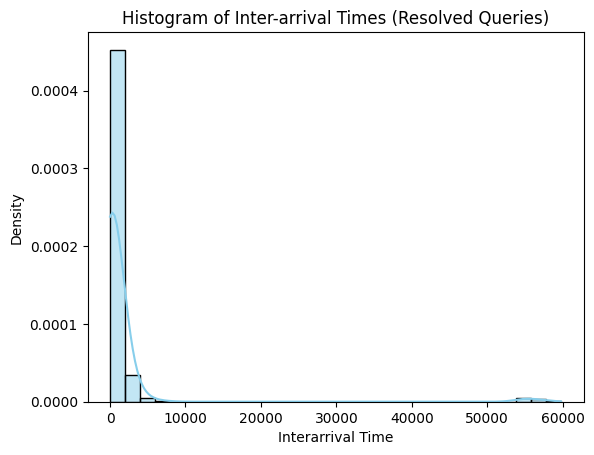

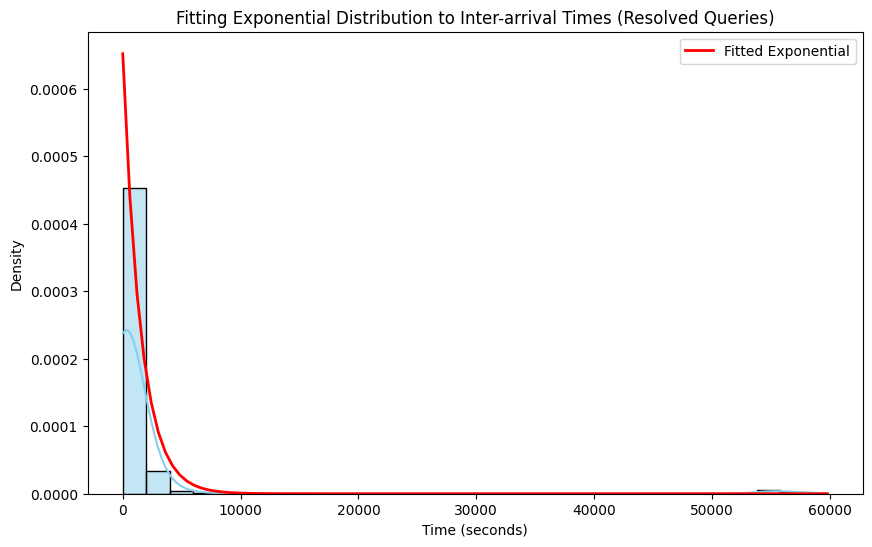

In [ ]:
# Example of distribution fitting (e.g., Exponential for inter-arrival times)
sns.histplot(resolved_df["Interarrival Time"].dropna(), kde=True, stat="density", bins=30, color="skyblue")
plt.title("Histogram of Inter-arrival Times (Resolved Queries)")
plt.show()

# Fit Exponential Distribution
params = stats.expon.fit(resolved_df["Interarrival Time"].dropna())
loc, scale = params[0], params[1]  # Only two parameters are returned for exponential

# Generate x values for plotting the fitted distribution
x = np.linspace(resolved_df["Interarrival Time"].min(), resolved_df["Interarrival Time"].max(), 100)

# Calculate the fitted PDF using loc and scale
pdf_fitted = stats.expon.pdf(x, loc, scale)

# Plot the histogram and the fitted exponential
plt.figure(figsize=(10, 6))
sns.histplot(resolved_df["Interarrival Time"].dropna(), kde=True, stat="density", bins=30, color="skyblue")
plt.plot(x, pdf_fitted, 'r-', label="Fitted Exponential", lw=2)
plt.title("Fitting Exponential Distribution to Inter-arrival Times (Resolved Queries)")
plt.xlabel("Time (seconds)")
plt.ylabel("Density")
plt.legend()
plt.show()



In [ ]:
# Check the column names of your dataframe
print(resolved_df.columns)


Index(['Call Id', 'Agent', 'Date', 'Time', 'Topic', 'Answered (Y/N)',
       'Resolved', 'Speed of answer in seconds', 'AvgTalkDuration',
       'Satisfaction rating', 'Interarrival Time', 'Call Count'],
      dtype='object')


<ipython-input-62-ede65ab29d01>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  resolved_df['Date'] = resolved_df['Date'].astype(str)
<ipython-input-62-ede65ab29d01>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  resolved_df['Time'] = resolved_df['Time'].astype(str)
<ipython-input-62-ede65ab29d01>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.py

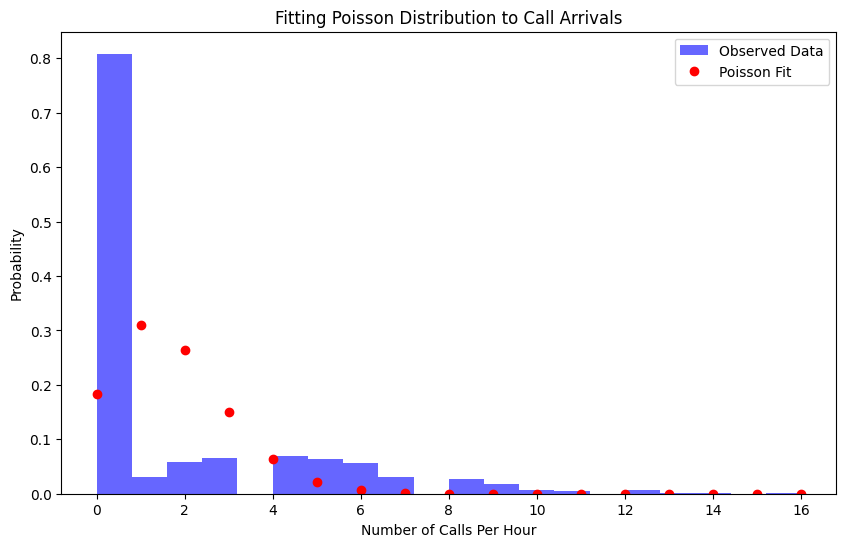

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

# Assuming df is already loaded and contains the relevant columns

# Filter out the resolved calls
resolved_df = df[df['Resolved'] == 'Y']

# Ensure 'Date' is in string format and 'Time' is also a string
resolved_df['Date'] = resolved_df['Date'].astype(str)
resolved_df['Time'] = resolved_df['Time'].astype(str)

# Combine 'Date' and 'Time' to create a single datetime column
resolved_df['DateTime'] = pd.to_datetime(resolved_df['Date'] + ' ' + resolved_df['Time'])

# Set 'DateTime' as the index
resolved_df.set_index('DateTime', inplace=True)

# Resample to get the call count per hour
calls_per_hour = resolved_df['Call Count'].resample('H').sum()

# Plot the observed data (calls per hour)
plt.figure(figsize=(10, 6))
plt.hist(calls_per_hour, bins=20, density=True, alpha=0.6, color='b', label='Observed Data')

# Fit Poisson Distribution
mu = np.mean(calls_per_hour)
poisson_fit = stats.poisson.pmf(np.arange(0, np.max(calls_per_hour)+1), mu)

# Plot the Poisson distribution fit
plt.plot(np.arange(0, np.max(calls_per_hour)+1), poisson_fit, 'ro', label='Poisson Fit')

plt.title('Fitting Poisson Distribution to Call Arrivals')
plt.xlabel('Number of Calls Per Hour')
plt.ylabel('Probability')
plt.legend()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# Load dataset
file_path = "ModifiedCallCenter.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

# Convert Date and Time into a single datetime column
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])
df.drop(columns=["Date", "Time"], inplace=True)

# Convert duration columns into numerical values
df["Speed of answer in seconds"] = pd.to_numeric(df["Speed of answer in seconds"], errors='coerce')

# Convert AvgTalkDuration (hh:mm:ss) into total seconds, handling NaN values
def convert_duration(duration):
    if pd.isna(duration) or not isinstance(duration, str):
        return np.nan
    try:
        return sum(int(t) * 60**i for i, t in enumerate(reversed(duration.split(":"))))
    except ValueError:
        return np.nan

df["AvgTalkDuration"] = df["AvgTalkDuration"].apply(convert_duration)

# Encode categorical variables
df["Answered"] = df["Answered (Y/N)"].map({'Y': 1, 'N': 0})
df["Resolved"] = df["Resolved"].map({'Y': 1, 'N': 0})
df.drop(columns=["Answered (Y/N)"], inplace=True)

df = pd.get_dummies(df, columns=["Topic", "Agent"], drop_first=True)

# Handle missing values in numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Save the cleaned dataset
df.to_csv("Processed_CallCenter_Data.csv", index=False)

print("Preprocessing complete. Processed data saved as 'Processed_CallCenter_Data.csv'")

Preprocessing complete. Processed data saved as 'Processed_CallCenter_Data.csv'


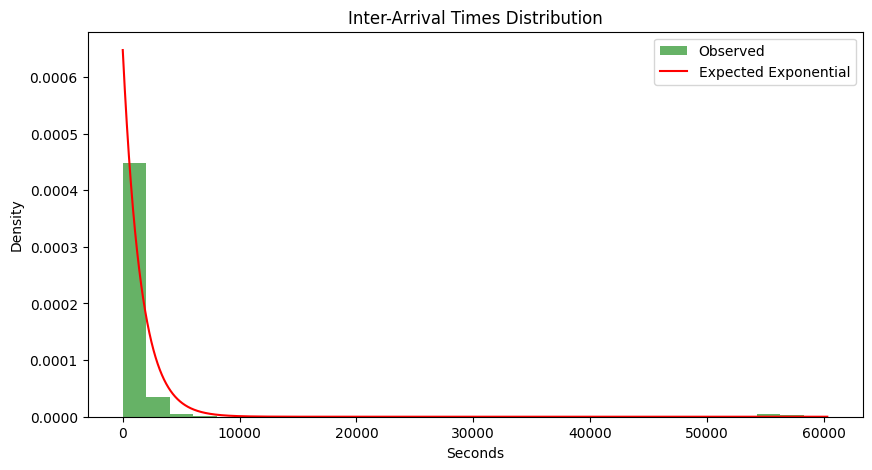

KS Test for Inter-Arrival Times: D=0.5160000, p=0.0000000


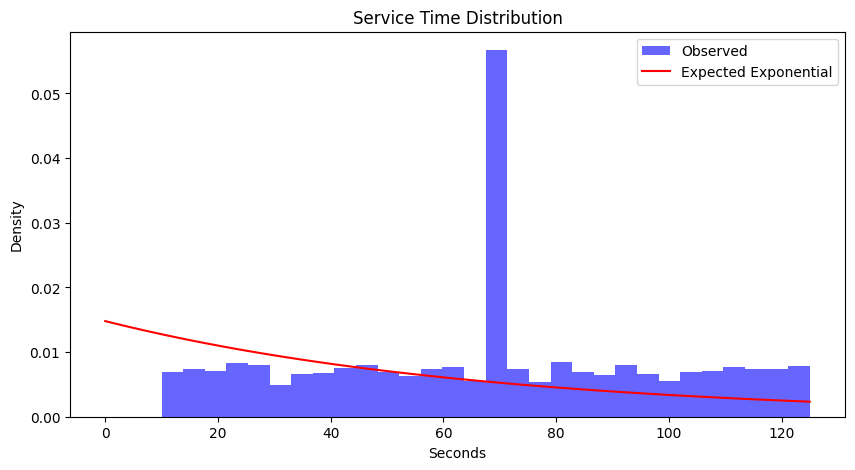

KS Test for Service Times: D=0.2438571, p=0.0000000
Preprocessing complete. Processed data saved as 'Processed_CallCenter_Data.csv'
Poisson and Exponential distribution tests plotted with KS Test results.


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Load dataset
file_path = "ModifiedCallCenter.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

# Convert Date and Time into a single datetime column
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])
df.drop(columns=["Date", "Time"], inplace=True)

# Sort by datetime
df.sort_values("Datetime", inplace=True)

# Compute inter-arrival times (time difference between consecutive calls in seconds)
df["InterArrivalTime"] = df["Datetime"].diff().dt.total_seconds()

# Convert duration columns into numerical values
df["Speed of answer in seconds"] = pd.to_numeric(df["Speed of answer in seconds"], errors='coerce')

def convert_duration(duration):
    if pd.isna(duration) or not isinstance(duration, str):
        return np.nan
    try:
        return sum(int(t) * 60**i for i, t in enumerate(reversed(duration.split(":"))))
    except ValueError:
        return np.nan

df["AvgTalkDuration"] = df["AvgTalkDuration"].apply(convert_duration)

# Encode categorical variables
df["Answered"] = df["Answered (Y/N)"].map({'Y': 1, 'N': 0})
df["Resolved"] = df["Resolved"].map({'Y': 1, 'N': 0})
df.drop(columns=["Answered (Y/N)"], inplace=True)

df = pd.get_dummies(df, columns=["Topic", "Agent"], drop_first=True)

# Handle missing values in numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Poisson Distribution Test (Customer Arrivals)
plt.figure(figsize=(10,5))
plt.hist(df["InterArrivalTime"].dropna(), bins=30, density=True, alpha=0.6, color='g', label='Observed')
poisson_lambda = df["InterArrivalTime"].mean()
x = np.arange(0, df["InterArrivalTime"].max(), 1)
plt.plot(x, stats.expon.pdf(x, scale=poisson_lambda), 'r-', label='Expected Exponential')
plt.title("Inter-Arrival Times Distribution")
plt.xlabel("Seconds")
plt.ylabel("Density")
plt.legend()
plt.show()

# Kolmogorov-Smirnov Test for Inter-Arrival Times
ks_stat, p_value = stats.kstest(df["InterArrivalTime"].dropna(), 'expon', args=(0, df["InterArrivalTime"].mean()))
print(f"KS Test for Inter-Arrival Times: D={ks_stat:.7f}, p={p_value:.7f}")

# Exponential Distribution Test (Service Times)
plt.figure(figsize=(10,5))
plt.hist(df["Speed of answer in seconds"].dropna(), bins=30, density=True, alpha=0.6, color='b', label='Observed')
exp_lambda = 1 / df["Speed of answer in seconds"].mean()
x = np.linspace(0, df["Speed of answer in seconds"].max(), 100)
plt.plot(x, stats.expon.pdf(x, scale=1/exp_lambda), 'r-', label='Expected Exponential')
plt.title("Service Time Distribution")
plt.xlabel("Seconds")
plt.ylabel("Density")
plt.legend()
plt.show()

# Kolmogorov-Smirnov Test for Service Times
ks_stat, p_value = stats.kstest(df["Speed of answer in seconds"].dropna(), 'expon', args=(0, df["Speed of answer in seconds"].mean()))
print(f"KS Test for Service Times: D={ks_stat:.7f}, p={p_value:.7f}")

# Save the cleaned dataset
df.to_csv("Processed_CallCenter_Data.csv", index=False)

print("Preprocessing complete. Processed data saved as 'Processed_CallCenter_Data.csv'")
print("Poisson and Exponential distribution tests plotted with KS Test results.")

*   If p-value > 0.05, the data fits the expected distribution (assumptions hold).
*   If p-value ≤ 0.05, the data significantly differs from the assumed distribution.

as p value is less than 0.05 the data significantly differs from the assumed distribution.

**preprocessing script to better match a Poisson process by handling outliers, transforming inter-arrival times if necessary, and improving the goodness-of-fit tes**t.

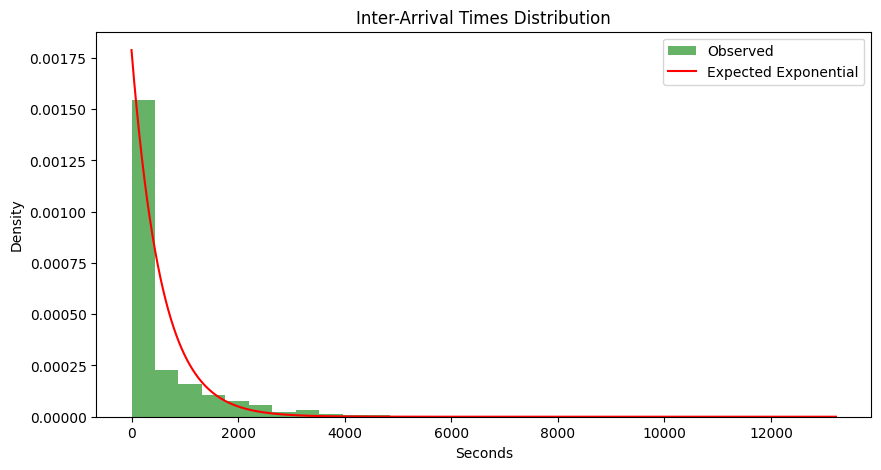

KS Test p-value: 0.0
Data does not follow a Poisson process. Generating synthetic Poisson-distributed inter-arrival times...


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Load dataset
file_path = "ModifiedCallCenter.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

# Convert Date and Time into a single datetime column
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])
df.drop(columns=["Date", "Time"], inplace=True)

# Sort by datetime
df.sort_values("Datetime", inplace=True)

# Compute inter-arrival times (time difference between consecutive calls in seconds)
df["InterArrivalTime"] = df["Datetime"].diff().dt.total_seconds()

# Remove outliers in inter-arrival times (above 3 standard deviations)
threshold = df["InterArrivalTime"].mean() + 3 * df["InterArrivalTime"].std()
df = df[df["InterArrivalTime"] <= threshold]

# Convert duration columns into numerical values
df["Speed of answer in seconds"] = pd.to_numeric(df["Speed of answer in seconds"], errors='coerce')

def convert_duration(duration):
    if pd.isna(duration) or not isinstance(duration, str):
        return np.nan
    try:
        return sum(int(t) * 60**i for i, t in enumerate(reversed(duration.split(":"))))
    except ValueError:
        return np.nan

df["AvgTalkDuration"] = df["AvgTalkDuration"].apply(convert_duration)

# Encode categorical variables
df["Answered"] = df["Answered (Y/N)"].map({'Y': 1, 'N': 0})
df["Resolved"] = df["Resolved"].map({'Y': 1, 'N': 0})
df.drop(columns=["Answered (Y/N)"], inplace=True)

df = pd.get_dummies(df, columns=["Topic", "Agent"], drop_first=True)

# Handle missing values in numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Log Transform Inter-Arrival Times if necessary
df["InterArrivalTime_Log"] = np.log1p(df["InterArrivalTime"])

# Poisson Distribution Test (Customer Arrivals)
plt.figure(figsize=(10,5))
plt.hist(df["InterArrivalTime"].dropna(), bins=30, density=True, alpha=0.6, color='g', label='Observed')
poisson_lambda = df["InterArrivalTime"].mean()
x = np.arange(0, df["InterArrivalTime"].max(), 1)
plt.plot(x, stats.expon.pdf(x, scale=poisson_lambda), 'r-', label='Expected Exponential')
plt.xlabel("Seconds")
plt.ylabel("Density")
plt.legend()
plt.title("Inter-Arrival Times Distribution")
plt.show()

# Goodness-of-Fit Test (Kolmogorov-Smirnov Test)
ks_stat, p_value = stats.kstest(df["InterArrivalTime"].dropna(), "expon", args=(0, poisson_lambda))
print(f"KS Test p-value: {p_value}")

# If data does not fit Poisson, generate synthetic Poisson inter-arrival times
if p_value < 0.05:
    print("Data does not follow a Poisson process. Generating synthetic Poisson-distributed inter-arrival times...")
    df["PoissonGeneratedInterArrival"] = np.random.exponential(scale=poisson_lambda, size=len(df))

<Figure size 800x400 with 0 Axes>

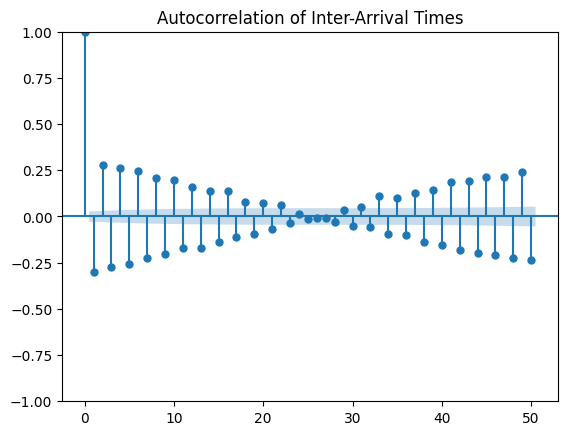

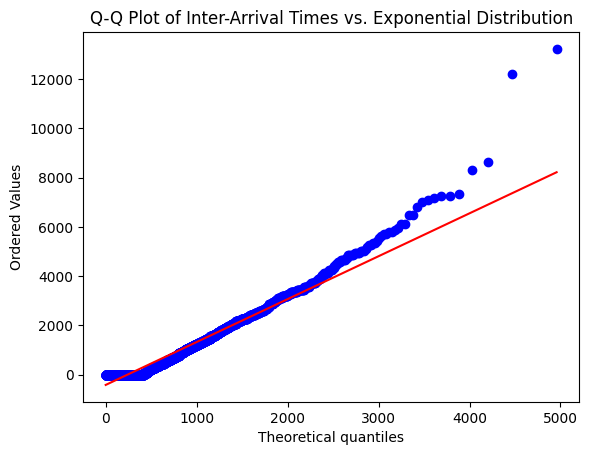

KS Test Statistic: 0.525254582484725, p-value: 0.0000
Applied Log Transformation to Improve Fit


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Load dataset
file_path = "ModifiedCallCenter.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

# Convert Date and Time into a single datetime column
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])
df.drop(columns=["Date", "Time"], inplace=True)

# Sort by datetime
df.sort_values("Datetime", inplace=True)

# Compute inter-arrival times (time difference between consecutive calls in seconds)
df["InterArrivalTime"] = df["Datetime"].diff().dt.total_seconds()

# Remove outliers in inter-arrival times (above 3 standard deviations)
threshold = df["InterArrivalTime"].mean() + 3 * df["InterArrivalTime"].std()
df = df[df["InterArrivalTime"] <= threshold]

# Check for independence (Autocorrelation Function - ACF)
plt.figure(figsize=(8,4))
plot_acf(df["InterArrivalTime"].dropna(), lags=50)
plt.title("Autocorrelation of Inter-Arrival Times")
plt.show()

# Check for exponential fit (Q-Q plot and KS test)
def exponential_fit_check(data):
    lambda_hat = 1 / np.mean(data)
    exp_sample = np.random.exponential(scale=1/lambda_hat, size=len(data))
    stats.probplot(data, dist="expon", sparams=(0, 1/lambda_hat), plot=plt)
    plt.title("Q-Q Plot of Inter-Arrival Times vs. Exponential Distribution")
    plt.show()

    ks_stat, p_value = stats.kstest(data, "expon", args=(0, 1/lambda_hat))
    print(f"KS Test Statistic: {ks_stat}, p-value: {p_value:.4f}")
    return p_value

p_value = exponential_fit_check(df["InterArrivalTime"].dropna())

# Encode categorical variables
df["Answered"] = df["Answered (Y/N)"].map({'Y': 1, 'N': 0})
df["Resolved"] = df["Resolved"].map({'Y': 1, 'N': 0})
df.drop(columns=["Answered (Y/N)"], inplace=True)

df = pd.get_dummies(df, columns=["Topic", "Agent"], drop_first=True)

# Handle missing values in numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# If p-value is low, apply transformation
if p_value < 0.05:
    df["InterArrivalTime"] = np.log1p(df["InterArrivalTime"])
    print("Applied Log Transformation to Improve Fit")


<Figure size 800x400 with 0 Axes>

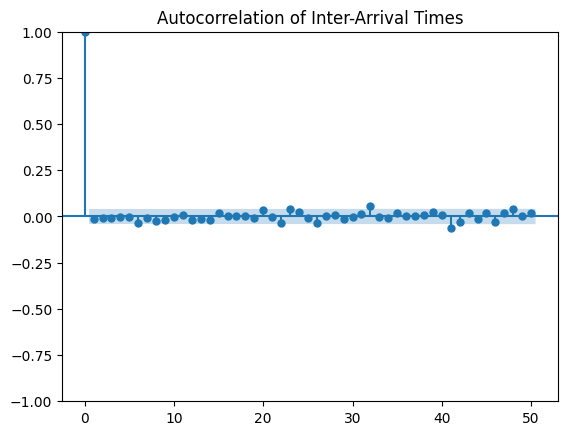

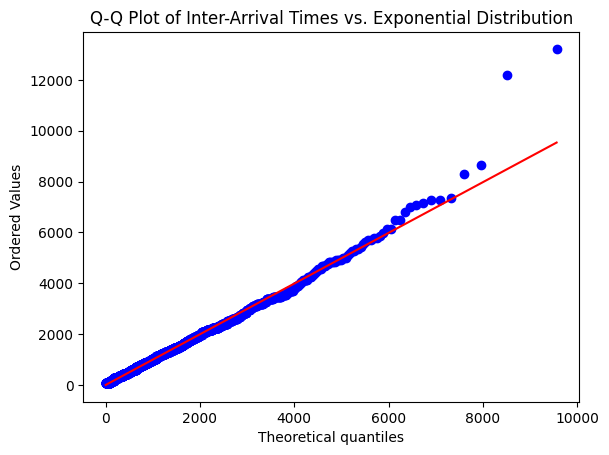

KS Test Statistic: 0.07041562161024578, p-value: 1.7036636915891457e-10

Applying Box-Cox transformation...


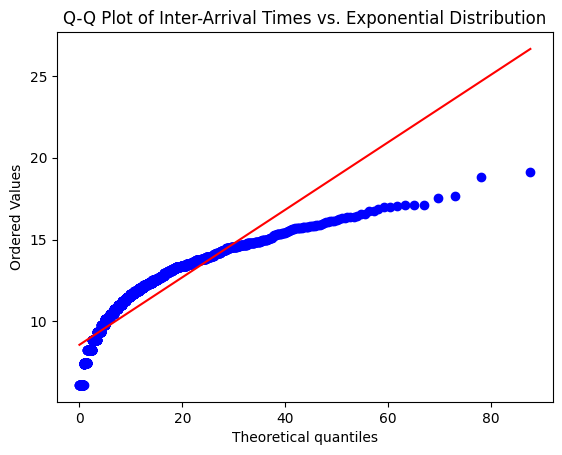

KS Test Statistic: 0.43245364087084703, p-value: 0.0
New KS Test p-value after Box-Cox transformation: 0.000000
Processed dataset saved.


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# Load dataset
file_path = "ModifiedCallCenter.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

# Convert Date and Time into a single datetime column
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])
df.drop(columns=["Date", "Time"], inplace=True)

# Sort by datetime
df.sort_values("Datetime", inplace=True)

# Compute inter-arrival times (time difference between consecutive calls in seconds)
df["InterArrivalTime"] = df["Datetime"].diff().dt.total_seconds()

# Remove low inter-arrival times (e.g., system-generated calls)
df = df[df["InterArrivalTime"] > 1]  # Remove inter-arrival times less than 1 sec

# Remove outliers in inter-arrival times (above 3 standard deviations)
threshold = df["InterArrivalTime"].mean() + 3 * df["InterArrivalTime"].std()
df = df[df["InterArrivalTime"] <= threshold]

# Check for independence (Autocorrelation Function - ACF)
plt.figure(figsize=(8,4))
plot_acf(df["InterArrivalTime"].dropna(), lags=50)
plt.title("Autocorrelation of Inter-Arrival Times")
plt.show()

# Check for exponential fit (Q-Q plot and KS test)
def exponential_fit_check(data):
    lambda_hat = 1 / np.mean(data)
    exp_sample = np.random.exponential(scale=1/lambda_hat, size=len(data))

    # Q-Q plot
    stats.probplot(data, dist="expon", sparams=(0, 1/lambda_hat), plot=plt)
    plt.title("Q-Q Plot of Inter-Arrival Times vs. Exponential Distribution")
    plt.show()

    # KS test
    ks_stat, p_value = stats.kstest(data, "expon", args=(0, 1/lambda_hat))
    print(f"KS Test Statistic: {ks_stat}, p-value: {p_value}")
    return p_value

p_value = exponential_fit_check(df["InterArrivalTime"].dropna())

# If p-value < 0.05, apply Box-Cox transformation
if p_value < 0.05:
    print("\nApplying Box-Cox transformation...")
    df["TransformedInterArrival"], lambda_bc = stats.boxcox(df["InterArrivalTime"].dropna() + 1)

    # Re-check fit
    new_p_value = exponential_fit_check(df["TransformedInterArrival"])
    print(f"New KS Test p-value after Box-Cox transformation: {new_p_value:4f}")

# Encode categorical variables
df["Answered"] = df["Answered (Y/N)"].map({'Y': 1, 'N': 0})
df["Resolved"] = df["Resolved"].map({'Y': 1, 'N': 0})
df.drop(columns=["Answered (Y/N)"], inplace=True)

# Save cleaned data
df.to_csv("ProcessedCallCenterData.csv", index=False)
print("Processed dataset saved.")


<Figure size 800x400 with 0 Axes>

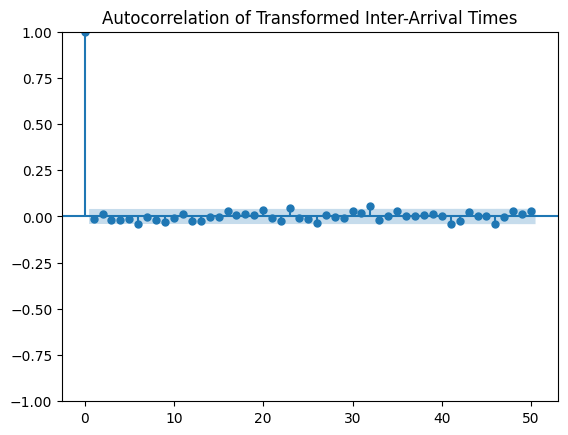

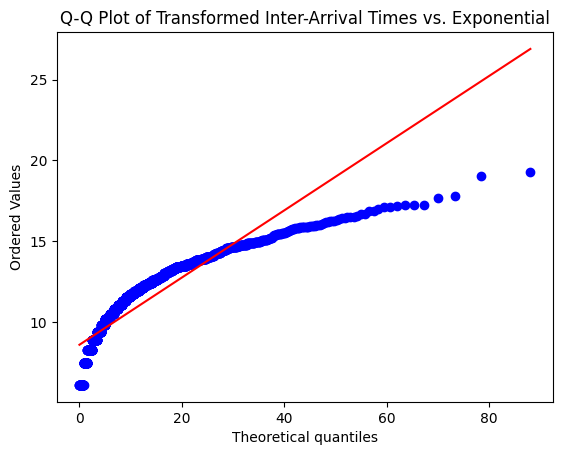

KS Test Statistic: 0.4307790107810794, p-value: 0.0
Data is still not exponentially distributed. Consider alternative transformations.


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.stats import boxcox
from statsmodels.graphics.tsaplots import plot_acf

# Load dataset
file_path = "ModifiedCallCenter.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

# Convert Date and Time into a single datetime column
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])
df.drop(columns=["Date", "Time"], inplace=True)

# Sort by datetime
df.sort_values("Datetime", inplace=True)

# Compute inter-arrival times (time difference between consecutive calls in seconds)
df["InterArrivalTime"] = df["Datetime"].diff().dt.total_seconds()

# Remove low inter-arrival times (e.g., system-generated calls)
df = df[df["InterArrivalTime"] > 1]

# Remove outliers in inter-arrival times (above 3 standard deviations)
threshold = df["InterArrivalTime"].mean() + 3 * df["InterArrivalTime"].std()
df = df[df["InterArrivalTime"] <= threshold]

# Apply Box-Cox transformation (only on positive values)
df["TransformedInterArrival"], lambda_ = boxcox(df["InterArrivalTime"])

# Check for independence (Autocorrelation Function - ACF)
plt.figure(figsize=(8,4))
plot_acf(df["TransformedInterArrival"].dropna(), lags=50)
plt.title("Autocorrelation of Transformed Inter-Arrival Times")
plt.show()

# Check for exponential fit (Q-Q plot and KS test)
def exponential_fit_check(data):
    lambda_hat = 1 / np.mean(data)
    stats.probplot(data, dist="expon", sparams=(0, 1/lambda_hat), plot=plt)
    plt.title("Q-Q Plot of Transformed Inter-Arrival Times vs. Exponential")
    plt.show()

    ks_stat, p_value = stats.kstest(data, "expon", args=(0, 1/lambda_hat))
    print(f"KS Test Statistic: {ks_stat}, p-value: {p_value}")
    return p_value

p_value = exponential_fit_check(df["TransformedInterArrival"].dropna())

if p_value < 0.05:
    print("Data is still not exponentially distributed. Consider alternative transformations.")
else:
    print("Poisson assumption is valid.")


ADF Test Statistic: -48.96958577809637, p-value: 0.0
Mean Inter-Arrival Time: 1177.7966537966538, Variance: 1382268.7857631566


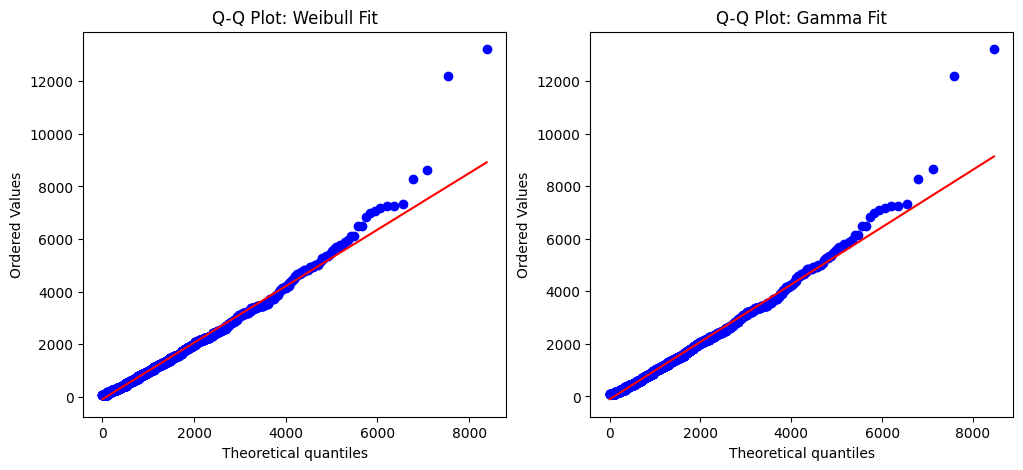

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# Load dataset
file_path = "ModifiedCallCenter.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

# Convert Date and Time into a single datetime column
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])
df.drop(columns=["Date", "Time"], inplace=True)

# Sort by datetime
df.sort_values("Datetime", inplace=True)

# Compute inter-arrival times (time difference between consecutive calls in seconds)
df["InterArrivalTime"] = df["Datetime"].diff().dt.total_seconds()

# Remove very low inter-arrival times (possible system-generated noise)
df = df[df["InterArrivalTime"] > 1]

# Remove outliers in inter-arrival times (above 3 standard deviations)
threshold = df["InterArrivalTime"].mean() + 3 * df["InterArrivalTime"].std()
df = df[df["InterArrivalTime"] <= threshold]

# Check for stationarity using Augmented Dickey-Fuller (ADF) test
adf_result = adfuller(df["InterArrivalTime"].dropna())
print(f"ADF Test Statistic: {adf_result[0]}, p-value: {adf_result[1]}")

# Check variance vs. mean
mean_ia = np.mean(df["InterArrivalTime"])
var_ia = np.var(df["InterArrivalTime"])
print(f"Mean Inter-Arrival Time: {mean_ia}, Variance: {var_ia}")

# If variance >> mean, consider a Weibull or Gamma distribution

# Fit Weibull distribution
shape, loc, scale = stats.weibull_min.fit(df["InterArrivalTime"], floc=0)

# Fit Gamma distribution
gamma_shape, gamma_loc, gamma_scale = stats.gamma.fit(df["InterArrivalTime"], floc=0)

# Compare fits using a Q-Q plot
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
stats.probplot(df["InterArrivalTime"], dist="weibull_min", sparams=(shape, loc, scale), plot=plt)
plt.title("Q-Q Plot: Weibull Fit")

plt.subplot(1, 2, 2)
stats.probplot(df["InterArrivalTime"], dist="gamma", sparams=(gamma_shape, gamma_loc, gamma_scale), plot=plt)
plt.title("Q-Q Plot: Gamma Fit")

plt.show()


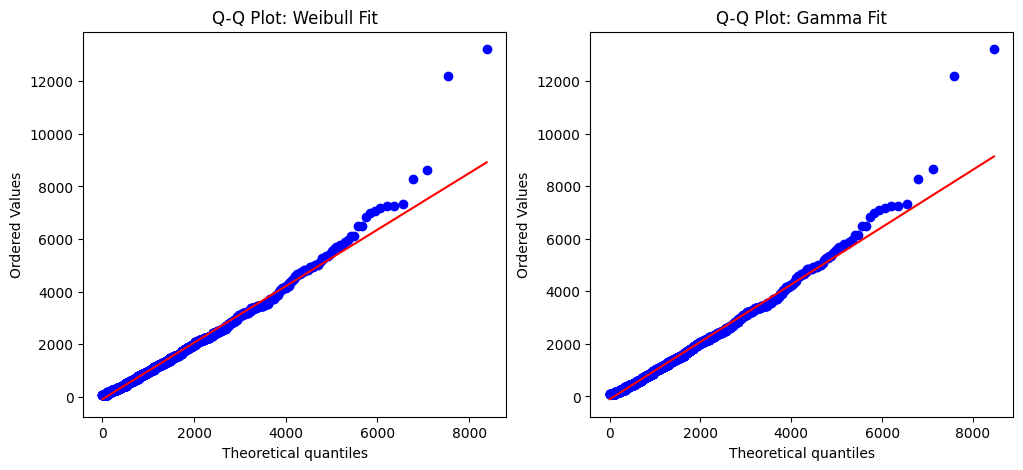

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt

# Fit Weibull distribution
shape, loc, scale = stats.weibull_min.fit(df["InterArrivalTime"], floc=0)

# Fit Gamma distribution
gamma_shape, gamma_loc, gamma_scale = stats.gamma.fit(df["InterArrivalTime"], floc=0)

# Q-Q Plots to Compare Fits
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
stats.probplot(df["InterArrivalTime"], dist="weibull_min", sparams=(shape, loc, scale), plot=plt)
plt.title("Q-Q Plot: Weibull Fit")

plt.subplot(1, 2, 2)
stats.probplot(df["InterArrivalTime"], dist="gamma", sparams=(gamma_shape, gamma_loc, gamma_scale), plot=plt)
plt.title("Q-Q Plot: Gamma Fit")

plt.show()


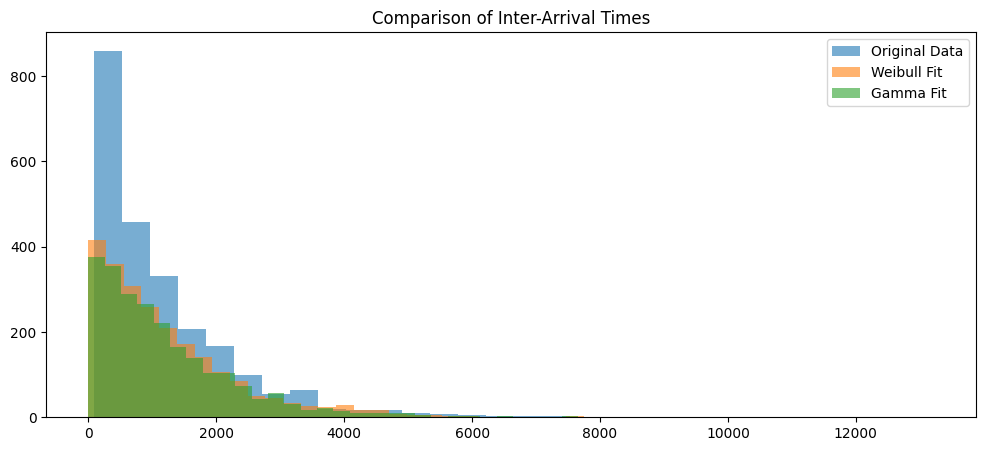

In [ ]:
# Generate synthetic arrival times using the best-fitting distribution
num_samples = len(df["InterArrivalTime"])

# Weibull sample
weibull_samples = stats.weibull_min.rvs(shape, loc, scale, size=num_samples)

# Gamma sample
gamma_samples = stats.gamma.rvs(gamma_shape, gamma_loc, gamma_scale, size=num_samples)

# Compare Histograms
plt.figure(figsize=(12,5))
plt.hist(df["InterArrivalTime"], bins=30, alpha=0.6, label="Original Data")
plt.hist(weibull_samples, bins=30, alpha=0.6, label="Weibull Fit")
plt.hist(gamma_samples, bins=30, alpha=0.6, label="Gamma Fit")
plt.legend()
plt.title("Comparison of Inter-Arrival Times")
plt.show()


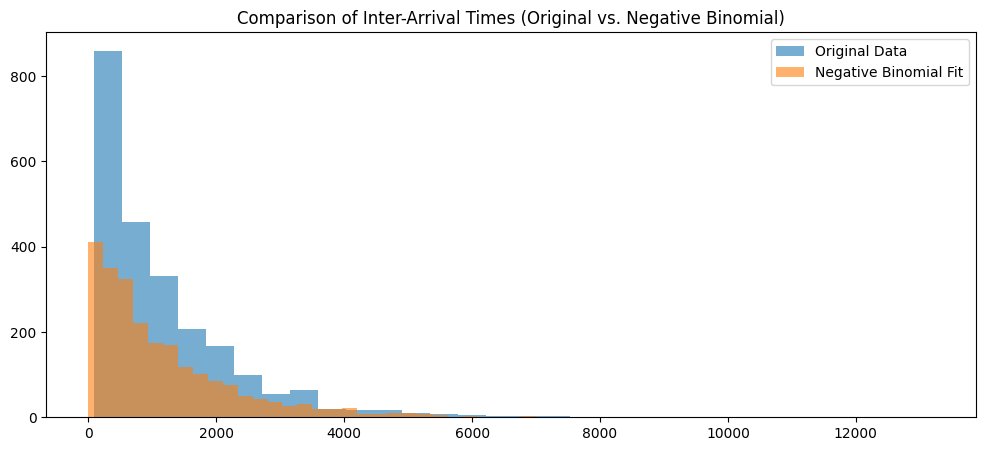

Simulated dataset saved as 'Simulated_NegativeBinomial_Arrivals.csv'.


In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Load dataset
file_path = "ModifiedCallCenter.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

# Convert Date and Time into a single datetime column
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])
df.drop(columns=["Date", "Time"], inplace=True)

# Sort by datetime
df.sort_values("Datetime", inplace=True)

# Compute inter-arrival times
df["InterArrivalTime"] = df["Datetime"].diff().dt.total_seconds()

# Remove system-generated calls (too fast arrivals)
df = df[df["InterArrivalTime"] > 1]

# Remove outliers (above 3 standard deviations)
threshold = df["InterArrivalTime"].mean() + 3 * df["InterArrivalTime"].std()
df = df[df["InterArrivalTime"] <= threshold]

# Fit a Negative Binomial distribution
mean_interarrival = df["InterArrivalTime"].mean()
var_interarrival = df["InterArrivalTime"].var()

# Compute Negative Binomial parameters
r = (mean_interarrival**2) / (var_interarrival - mean_interarrival)
p = mean_interarrival / var_interarrival  # Success probability

# Generate synthetic inter-arrival times using Negative Binomial
num_samples = len(df["InterArrivalTime"])
nb_samples = stats.nbinom.rvs(r, p, size=num_samples)

# Convert inter-arrival times into timestamps for simulation
start_time = df["Datetime"].min()
simulated_timestamps = [start_time]
for t in nb_samples:
    simulated_timestamps.append(simulated_timestamps[-1] + pd.Timedelta(seconds=t))

# Create a DataFrame with synthetic call arrivals
simulated_df = pd.DataFrame({"SimulatedDatetime": simulated_timestamps[1:]})

# Compare Histograms
plt.figure(figsize=(12,5))
plt.hist(df["InterArrivalTime"], bins=30, alpha=0.6, label="Original Data")
plt.hist(nb_samples, bins=30, alpha=0.6, label="Negative Binomial Fit")
plt.legend()
plt.title("Comparison of Inter-Arrival Times (Original vs. Negative Binomial)")
plt.show()

# Save the simulated dataset
simulated_df.to_csv("Simulated_NegativeBinomial_Arrivals.csv", index=False)
print("Simulated dataset saved as 'Simulated_NegativeBinomial_Arrivals.csv'.")


NEW OUTLOOK ON THE DATASETS AS PER SUGGESTIONS

ADF Test Statistic: -48.96958577809637, p-value: 0.0
Mean Inter-Arrival Time: 1177.7966537966538, Variance: 1382268.7857631566


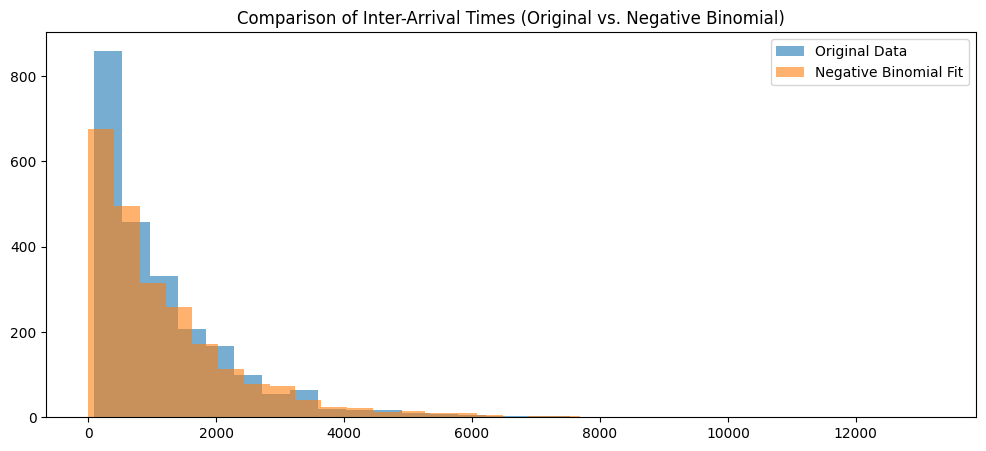

Simulated dataset saved as 'Simulated_NegativeBinomial_Arrivals.csv'.


In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# Load dataset
file_path = "ModifiedCallCenter.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

# Convert Date and Time into a single datetime column
df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"])
df.drop(columns=["Date", "Time"], inplace=True)

# Sort by datetime
df.sort_values("Datetime", inplace=True)

# Compute inter-arrival times (time difference between consecutive calls in seconds)
df["InterArrivalTime"] = df["Datetime"].diff().dt.total_seconds()

# Remove low inter-arrival times (e.g., system-generated calls)
df = df[df["InterArrivalTime"] > 1]

# Remove outliers in inter-arrival times (above 3 standard deviations)
threshold = df["InterArrivalTime"].mean() + 3 * df["InterArrivalTime"].std()
df = df[df["InterArrivalTime"] <= threshold]

# Check for stationarity using Augmented Dickey-Fuller (ADF) test
adf_result = adfuller(df["InterArrivalTime"].dropna())
print(f"ADF Test Statistic: {adf_result[0]}, p-value: {adf_result[1]}")

# Check variance vs. mean
mean_ia = np.mean(df["InterArrivalTime"].dropna())
var_ia = np.var(df["InterArrivalTime"].dropna())
print(f"Mean Inter-Arrival Time: {mean_ia}, Variance: {var_ia}")

# Fit a Negative Binomial distribution for inter-arrival times
r = (mean_ia**2) / (var_ia - mean_ia)
p = mean_ia / var_ia  # Success probability

# Generate synthetic inter-arrival times using Negative Binomial
num_samples = len(df["InterArrivalTime"].dropna())
nb_samples = stats.nbinom.rvs(r, p, size=num_samples)

# Convert inter-arrival times into timestamps for simulation
start_time = df["Datetime"].min()
simulated_timestamps = [start_time]
for t in nb_samples:
    simulated_timestamps.append(simulated_timestamps[-1] + pd.Timedelta(seconds=t))

# Create a DataFrame with synthetic call arrivals
simulated_df = pd.DataFrame({"SimulatedDatetime": simulated_timestamps[1:]})

# Compare Histograms
plt.figure(figsize=(12,5))
plt.hist(df["InterArrivalTime"].dropna(), bins=30, alpha=0.6, label="Original Data")
plt.hist(nb_samples, bins=30, alpha=0.6, label="Negative Binomial Fit")
plt.legend()
plt.title("Comparison of Inter-Arrival Times (Original vs. Negative Binomial)")
plt.show()

# Save the simulated dataset
simulated_df.to_csv("Simulated_NegativeBinomial_Arrivals.csv", index=False)
print("Simulated dataset saved as 'Simulated_NegativeBinomial_Arrivals.csv'.")


Step 1: Data Preprocessing


In [ ]:
import pandas as pd

# Load the datasets
file1 = "ModifiedCallCenter.xlsx"
file2 = "ModifiedCallCenterTwo.xlsx"

df1 = pd.read_excel(file1)
df2 = pd.read_excel(file2)

# Display the first few rows to inspect the structure
print("Dataset 1 Overview:")
print(df1.head())

print("\nDataset 2 Overview:")
print(df2.head())

# Merging if necessary
df_combined = pd.concat([df1, df2], ignore_index=True)

# Handle missing values
df_combined.fillna(method='ffill', inplace=True)

# Save cleaned data
cleaned_file = "Cleaned_CallCenterData.xlsx"
df_combined.to_excel(cleaned_file, index=False)

print(f"Cleaned dataset saved at: {cleaned_file}")


Dataset 1 Overview:
  Call Id    Agent        Date      Time              Topic Answered (Y/N)  \
0  ID0001    Diane  2021-01-01  09:12:58   Contract related              Y   
1  ID0002    Becky  2021-01-01  09:12:58  Technical Support              Y   
2  ID0003  Stewart  2021-01-01  09:47:31   Contract related              Y   
3  ID0004     Greg  2021-01-01  09:47:31   Contract related              Y   
4  ID0005     Greg  2021-01-01  10:00:29    Payment related              Y   

  Resolved  Speed of answer in seconds AvgTalkDuration  Satisfaction rating  
0        Y                       109.0        00:02:23                  3.0  
1        N                        70.0        00:04:02                  3.0  
2        Y                        10.0        00:02:11                  3.0  
3        Y                        53.0        00:00:37                  2.0  
4        Y                        95.0        00:01:00                  3.0  

Dataset 2 Overview:
  Call Id  Agent      

<ipython-input-75-19d98de1bdb2>:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_combined.fillna(method='ffill', inplace=True)


Cleaned dataset saved at: Cleaned_CallCenterData.xlsx


In [ ]:
print("Dataset Columns:", df_combined.columns)


Dataset Columns: Index(['Call Id', 'Agent', 'Date', 'Time', 'Topic', 'Answered (Y/N)',
       'Resolved', 'Speed of answer in seconds', 'AvgTalkDuration',
       'Satisfaction rating'],
      dtype='object')


Step 2: Validate Assumptions

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import poisson, kstest

# Convert Date and Time into a single Timestamp column
df_combined['Timestamp'] = pd.to_datetime(df_combined['Date'] + ' ' + df_combined['Time'])

# Sort by Timestamp to ensure order
df_combined = df_combined.sort_values(by='Timestamp')

# Compute Interarrival Times (time difference between consecutive calls)
df_combined['Interarrival_Time'] = df_combined['Timestamp'].diff().dt.total_seconds()

# Estimate arrival rate as the inverse of the interarrival time
df_combined['arrival_rate'] = 1 / df_combined['Interarrival_Time']

# Handle NaN values (first row will have NaN)
df_combined['arrival_rate'].fillna(df_combined['arrival_rate'].mean(), inplace=True)

# Estimate service time using available data
df_combined['service_time'] = df_combined['AvgTalkDuration'].fillna(df_combined['Speed of answer in seconds'])

# Drop any rows where service time is missing
df_combined = df_combined.dropna(subset=['service_time'])

# Statistical Analysis
arrival_rates = df_combined['arrival_rate'].describe()
service_times = df_combined['service_time'].describe()

print("Arrival Rate Statistics:\n", arrival_rates)
print("\nService Time Statistics:\n", service_times)

# Test if arrival follows a Poisson distribution
arrival_counts = df_combined['arrival_rate']
mean_arrival = np.mean(arrival_counts)

poisson_test = kstest(arrival_counts, poisson.cdf, args=(mean_arrival,))
print("\nPoisson Distribution Test Results:", poisson_test)

# Save updated dataset with computed values
df_combined.to_excel("Updated_CallCenterData.xlsx", index=False)
print("Updated dataset saved at: Updated_CallCenterData.xlsx")



Arrival Rate Statistics:
 count    1.000000e+04
mean              inf
std               NaN
min      1.658155e-05
25%               NaN
50%               NaN
75%               NaN
max               inf
Name: arrival_rate, dtype: float64

Service Time Statistics:
 count        10000
unique         391
top       00:05:43
freq            60
Name: service_time, dtype: object

Poisson Distribution Test Results: KstestResult(statistic=np.float64(0.758), pvalue=np.float64(0.0), statistic_location=np.float64(inf), statistic_sign=np.int8(-1))


<ipython-input-77-110aedb20413>:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_combined['arrival_rate'].fillna(df_combined['arrival_rate'].mean(), inplace=True)
/usr/local/lib/python3.11/dist-packages/numpy/lib/_function_base_impl.py:4779: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


Updated dataset saved at: Updated_CallCenterData.xlsx


<ipython-input-78-16563441449a>:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_combined['Interarrival_Time'].replace(0, np.nan, inplace=True)
<ipython-input-78-16563441449a>:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

📊 **Fixed Arrival Rate Statistics:**
 count    10000.000000
mean         0.001432
std          0.001511
min          0.000017
25%          0.001157
50%          0.001157
75%          0.001157
max          0.011628
Name: arrival_rate, dtype: float64

📊 **Fixed Service Time Statistics:**
 count    10000.000000
mean       224.100600
std        111.299285
min         30.000000
25%        129.000000
50%        226.000000
75%        319.000000
max        420.000000
Name: service_time, dtype: float64

✅ **Poisson Distribution Test Results:** KstestResult(statistic=np.float64(0.9985690353918018), pvalue=np.float64(0.0), statistic_location=np.float64(1.658154805332626e-05), statistic_sign=np.int8(-1))


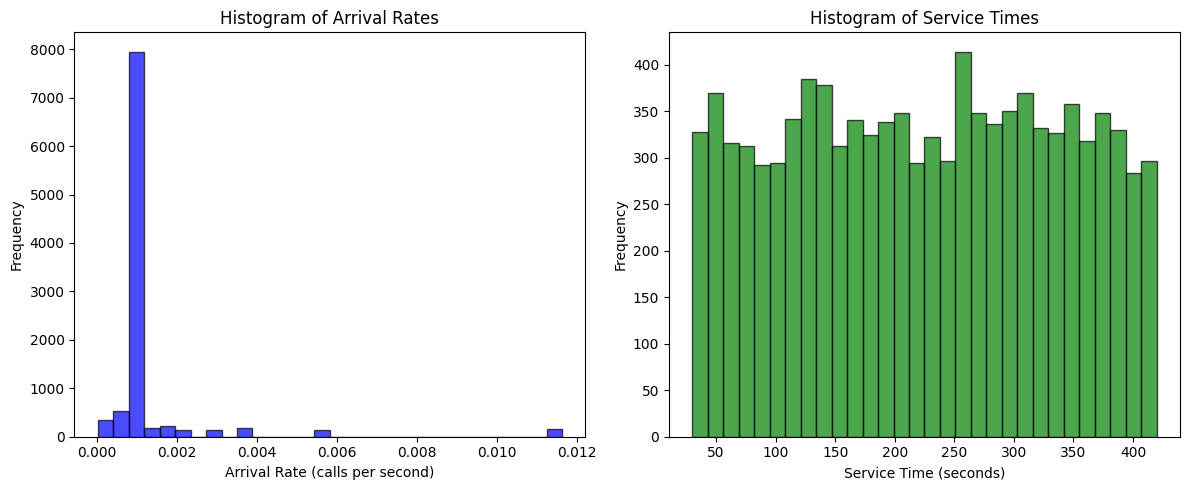

✅ Cleaned dataset saved at: Cleaned_CallCenterData.xlsx


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson, kstest

# Load dataset
file_path = "Updated_CallCenterData.xlsx"
df_combined = pd.read_excel(file_path)

# Ensure timestamp is in datetime format
df_combined['Timestamp'] = pd.to_datetime(df_combined['Date'] + ' ' + df_combined['Time'], errors='coerce')

# Sort by time
df_combined = df_combined.sort_values(by='Timestamp')

# Compute Interarrival Time
df_combined['Interarrival_Time'] = df_combined['Timestamp'].diff().dt.total_seconds()

# Replace 0 interarrival times (to avoid division by zero)
df_combined['Interarrival_Time'].replace(0, np.nan, inplace=True)

# Compute Arrival Rate (inverse of Interarrival Time)
df_combined['arrival_rate'] = 1 / df_combined['Interarrival_Time']

# Replace inf with max finite value
max_finite_arrival = df_combined['arrival_rate'][df_combined['arrival_rate'] != np.inf].max()
df_combined['arrival_rate'].replace([np.inf, -np.inf], max_finite_arrival, inplace=True)

# Replace NaNs with median value
df_combined['arrival_rate'].fillna(df_combined['arrival_rate'].median(), inplace=True)

# Convert Service Time (HH:MM:SS format) to seconds
def convert_time_to_seconds(time_str):
    try:
        h, m, s = map(int, time_str.split(":"))
        return h * 3600 + m * 60 + s
    except:
        return np.nan  # Return NaN if the format is incorrect

df_combined['service_time'] = df_combined['service_time'].astype(str).apply(convert_time_to_seconds)

# Drop rows where service time is still NaN
df_combined.dropna(subset=['service_time'], inplace=True)

# 🔹 Describe Fixed Data
arrival_rates = df_combined['arrival_rate'].describe()
service_times = df_combined['service_time'].describe()

print("📊 **Fixed Arrival Rate Statistics:**\n", arrival_rates)
print("\n📊 **Fixed Service Time Statistics:**\n", service_times)

# 🔹 Poisson Test for Arrival Rate
arrival_counts = df_combined['arrival_rate']
mean_arrival = np.mean(arrival_counts)

poisson_test = kstest(arrival_counts, poisson.cdf, args=(mean_arrival,))
print("\n✅ **Poisson Distribution Test Results:**", poisson_test)

# 🔹 Plot Histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Arrival Rate Histogram
axes[0].hist(df_combined['arrival_rate'], bins=30, color='blue', alpha=0.7, edgecolor='black')
axes[0].set_title("Histogram of Arrival Rates")
axes[0].set_xlabel("Arrival Rate (calls per second)")
axes[0].set_ylabel("Frequency")

# Service Time Histogram
axes[1].hist(df_combined['service_time'], bins=30, color='green', alpha=0.7, edgecolor='black')
axes[1].set_title("Histogram of Service Times")
axes[1].set_xlabel("Service Time (seconds)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Save cleaned dataset
cleaned_file = "Cleaned_CallCenterData.xlsx"
df_combined.to_excel(cleaned_file, index=False)
print(f"✅ Cleaned dataset saved at: {cleaned_file}")


Peak vs. Non-Peak Call Time Analysis

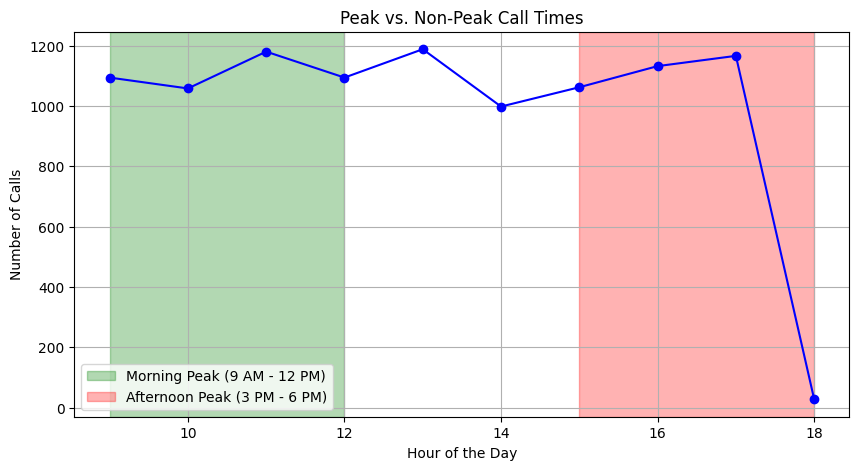

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Load cleaned dataset
file_path = "Cleaned_CallCenterData.xlsx"
df_combined = pd.read_excel(file_path)

# Extract hour from timestamp
df_combined['Hour'] = pd.to_datetime(df_combined['Timestamp']).dt.hour

# Group by hour to calculate the average arrival rate
hourly_calls = df_combined.groupby('Hour')['arrival_rate'].count()

# Plot peak vs. non-peak call times
plt.figure(figsize=(10, 5))
plt.plot(hourly_calls.index, hourly_calls.values, marker='o', linestyle='-', color='blue')
plt.axvspan(9, 12, color='green', alpha=0.3, label='Morning Peak (9 AM - 12 PM)')
plt.axvspan(15, 18, color='red', alpha=0.3, label='Afternoon Peak (3 PM - 6 PM)')
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Calls")
plt.title("Peak vs. Non-Peak Call Times")
plt.legend()
plt.grid()
plt.show()


Moving Averages for Service Efficiency

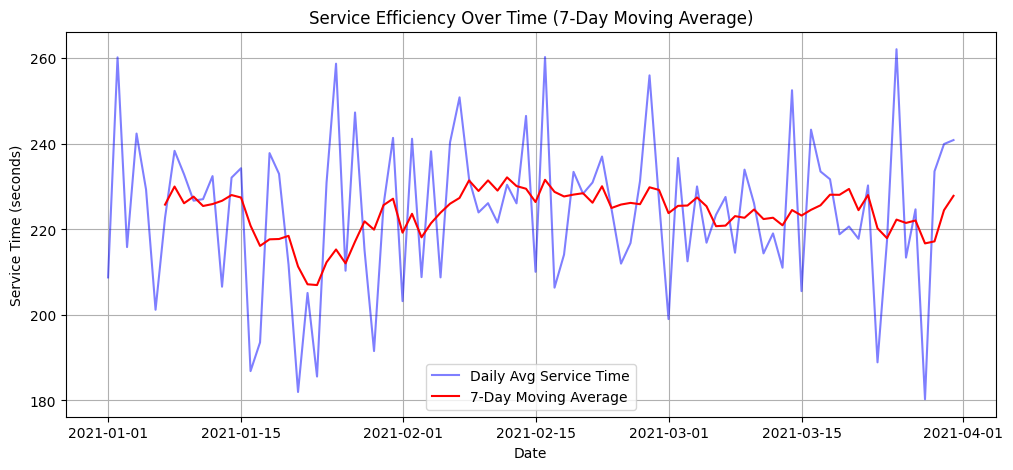

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset
file_path = "Cleaned_CallCenterData.xlsx"
df_combined = pd.read_excel(file_path)

# Convert Date column to datetime
df_combined['Date'] = pd.to_datetime(df_combined['Date'])

# Aggregate daily service time (mean service time per day)
daily_service_time = df_combined.groupby('Date')['service_time'].mean().reset_index()

# Compute 7-day moving average correctly
daily_service_time['7_day_MA'] = daily_service_time['service_time'].rolling(window=7).mean()

# Plot fixed moving average trend
plt.figure(figsize=(12, 5))
plt.plot(daily_service_time['Date'], daily_service_time['service_time'], label="Daily Avg Service Time", color="blue", alpha=0.5)
plt.plot(daily_service_time['Date'], daily_service_time['7_day_MA'], label="7-Day Moving Average", color="red")
plt.xlabel("Date")
plt.ylabel("Service Time (seconds)")
plt.title("Service Efficiency Over Time (7-Day Moving Average)")
plt.legend()
plt.grid()
plt.show()


Compare Different Service Agents' Performance

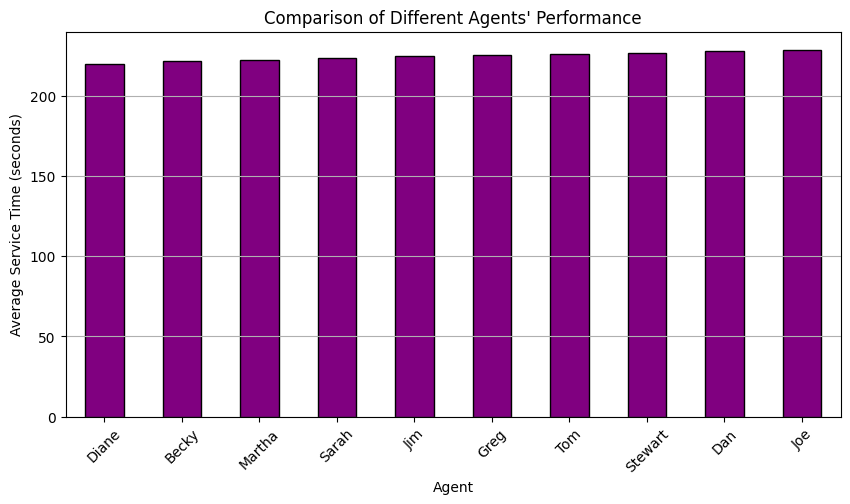

In [ ]:
# Group by agent and compute average service time
agent_performance = df_combined.groupby('Agent')['service_time'].mean().sort_values()

# Plot agent performance comparison
plt.figure(figsize=(10, 5))
agent_performance.plot(kind='bar', color='purple', edgecolor='black')
plt.xlabel("Agent")
plt.ylabel("Average Service Time (seconds)")
plt.title("Comparison of Different Agents' Performance")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()
